# Tennessee Eastman Process — Modellbildung

Lädt die Rohdaten `data_train`/`data_test`/`data_error` aus *tep_generation*, trainiert/lädt ein MLP auf den stationären Trainingsphasen, wertet den Prädiktionsfehler auf Test- und Fehlerfalldaten aus und speichert die gescorten Artefakte `data_scored_production`/`data_scored_error` für *tep_detection* und *tep_adaptation*.

In [1]:
import os
from pathlib import Path

work_dir = os.getcwd()
DEFAULT_BASE_DIR = os.path.normpath(os.path.join(work_dir, "..", ".."))

base_dir = Path(os.environ.get("BASE_DIR", DEFAULT_BASE_DIR)).resolve()
data_dir = base_dir / "data" / "tep"
model_dir = base_dir / "models"
plot_dir = base_dir / "plots"
results_dir = base_dir / "results"

for _d in (data_dir, model_dir, plot_dir, results_dir):
    os.makedirs(_d, exist_ok=True)

FORCE_RECOMPUTE = False
IS_FINAL = True  

In [2]:
import numpy as np

In [3]:
# --- Konstanten ---
SEED = 42
# Kennung des *Produktionslaufs* -- die "Data Run-ID" aus der Schlusszelle von
# tep_generation. Die Kampagnenkennung wird daraus als cfg.base_id abgeleitet.
RUN_ID = "6fe76fde" # None
# Fehlerfall explizit waehlen. Mit None nimmt load_section das *neueste*
# Artefakt nach Dateidatum -- sobald mehrere Amplituden vorliegen, ist damit
# nicht mehr eindeutig, welche ausgewertet wird.
ERROR_VARIANT = {"idv": 29, "amp": 0.3}
WINDOW_SIZE = 10
ARCH = [8, 8, 1]
ACT = "tanh"
EPOCHS = 200
BATCH = 200
PATIENCE = 20
VAL_SPLIT = 0.15

DROP_OUTLIERS = False   # z-Score-Filter; im DOE-Datensatz trifft er ganze Betriebspunkte
N_FEATURES = 5          # Merkmale der Vorwaertsselektion
# Woher die Validierungsmenge des Early Stopping kommt:
#   "ramp"    -- Anfahrrampen aller Kampagnenpunkte. Der Block ist RAMP+SOAK
#                lang, trainiert wird auf dem Halteintervall; die erste Haelfte
#                blieb bisher ungenutzt. Deckt alle Punkte ab, kostet keinen,
#                und ist echtes Fremdmaterial (10.3: R2 0.954 / 0.927 zwischen
#                beiden Haelften).
#   "segment" -- ganze Betriebspunkte herausnehmen. Bei 18 Punkten sind das
#                drei; val_loss ist dann so klein, dass die beste Epoche die
#                erste ist und das Early Stopping sofort greift.
#   "random"  -- zufaelliger Zeilensplit. Nach der Glaettung sind Nachbar-
#                zeitpunkte fast identisch, das Early Stopping greift nie (2.2b).
VAL_MODE = "ramp"       # "ramp" | "segment" | "random"

# Messgroesse, auf die IDV(29) als Kalibrierdrift wirkt (XMEAS(18), in
# temexd_mod.c ueber DRIFT_SENSOR_INDEX). Sie muss Eingang des Modells sein,
# sonst kann der Drift den Praediktionsfehler gar nicht erreichen. Die
# Vorwaertsselektion startet deshalb mit ihr und fuellt den Rest wie bisher auf.
SENSOR_FEATURE = "Stripper Temp"

# Groesse der Kampagne.  campaign_data enthaelt alle gefahrenen Betriebspunkte;
# trainiert wird nur auf einer Teilmenge, sonst hat das Modell jeden
# Produktionspunkt schon gesehen und der Abstand ist ueberall null.  Reiner
# Auswertungsparameter -- die Lernkurve entsteht durch Variation dieser Zahl,
# ohne eine einzige neue Simulation.
N_CAMPAIGN = 18

# Merkmalssatz. "select" waehlt die vier Merkmale neben SENSOR_FEATURE per
# Vorwaertsselektion aus den Kampagnendaten, "fixed" nimmt FEATURE_SET.
#
# Die Vorwaertsselektion mit Leave-one-out ueber wenige Betriebspunkte ist nicht
# stabil -- das Screening zeigt, dass sie unter 30 Punkten bei jeder Groesse
# etwas anderes waehlt. FEATURE_SET ist stattdessen aus der Kostenzerlegung
# begruendet (Handoff 3): 78 % der Kosten sind Purge-Verluste, deren Rate das
# Purge-Ventil stellt; von den sieben Purge-Komponenten heben nur D und E die
# Gesamtkosten, stromaufwaerts fuer E ist die E-Zufuhr zum Reaktor; was ins
# Purge gelangt statt zu kondensieren, entscheidet die Separatortemperatur;
# MolePctGSP ist die geregelte Rezepturgroesse, die die sechs Modi trennt.
# Stripper Temp ist nicht praediktiv, sondern konstruktiv gesetzt: ohne den
# Wirkort der Sensordrift kann der Drift den Praediktionsfehler nicht erreichen.
FEATURE_MODE = "fixed"        # "fixed" | "select"
FEATURE_SET = ["Stripper Temp", "Purge valve", "Component E to Reactor",
               "Product Sep Temp", "MolePctGSP"]

SAMPLES_PER_H = 20
PLOT_FRAC = 0.1              # Anteil geplotteter Punkte
PLOT_YLIM = (-1e2, 1e2)      # symlog-Bereich der Fehlerachse
PLOT_EPOCH = "1970-01-01"    # Zeitstempel-Ursprung wie im synthetischen Fall

rng = np.random.default_rng(SEED)

## Daten laden

In [4]:
import run_registry as rr
data_store = rr.tep_data_store(data_dir)
model_store = rr.tep_model_store(model_dir)
plot_store = rr.tep_plot_store(plot_dir)
res_store = rr.tep_results_store(results_dir)

# Zwei Konfigurationsebenen (s. tep_generation):
#   base_cfg -- Versuchsplan, traegt data_campaign (= Prerun, der Kampagnenlauf)
#   cfg      -- plus Laufparameter, traegt data_production und data_error
#
# Eingestiegen wird ueber den Produktionslauf, weil tep_generation dessen
# Kennung ausgibt.  Die Kampagnenkennung wird daraus abgeleitet (cfg.base_id)
# und nicht geraten -- latest_id() waehlt nur nach Dateidatum und kann bei
# mehreren Artefakten daneben greifen.
prod_id = data_store.latest_id("data_production") if RUN_ID is None else RUN_ID
if prod_id is None:
    raise FileNotFoundError("Kein production-Artefakt. Bitte tep_generation.ipynb ausfuehren.")
production_data = data_store.load("data_production", run_id=prod_id, rename=True)
cfg = rr.RunConfig.from_document(production_data.attrs.get("config", production_data.attrs))

try:
    campaign_data = data_store.load("data_campaign", run_id=cfg.base_id, rename=True)
except FileNotFoundError:
    import glob as _g, os as _o, json as _j
    _av = []
    for _p in _g.glob(_o.path.join(str(data_dir), f"{data_store.prefix}_data_campaign_*.json")):
        with open(_p, encoding="utf-8") as _f:
            _av.append(_j.load(_f).get("id"))
    raise FileNotFoundError(
        f"Kampagnenartefakt zu base_id={cfg.base_id} fehlt. Vorhanden: {_av}. "
        "Der Produktionslauf gehoert dann zu einem anderen Versuchsplan -- "
        "tep_generation mit demselben Stand durchlaufen lassen.")
base_cfg = rr.RunConfig.from_document(campaign_data.attrs.get("config", campaign_data.attrs))

run_cfg = dict(base_cfg.document)
ramp_duration = run_cfg["ramp_h"]
soak_time = run_cfg["soak_h"]

# Fehlerfall: eigene Kennung aus Basis + error-Sektion. Mit ERROR_VARIANT wird sie
# direkt berechnet, ohne Vorgabe das neueste Artefakt genommen und geprueft.
error_data, error_cfg = rr.load_section(data_store, "data_error", cfg, "error",
                                        ERROR_VARIANT)
error_variant = error_cfg.sections["error"]
ERROR_VARIANT_ID = error_variant["idv"]
if "driftf" not in error_data.columns:
    raise ValueError("data_error hat keine Spalte 'driftf'. Bitte die Zelle "
                     "'Gemessenes driftf als Spalte' in tep_generation ausfuehren.")

print(f"base_id = {base_cfg.id} | run_id = {cfg.id} | error_run_id = {error_cfg.id} "
      f"(IDV {ERROR_VARIANT_ID}, amp {error_variant['amp']})")
print(f"Kampagnenpool {campaign_data['mode'].nunique()} Punkte, "
      f"Produktion {production_data['mode'].nunique()} Punkte, "
      f"Fehlerfall {error_data['mode'].nunique()} Punkte")

base_id = 30098669 | run_id = 6fe76fde | error_run_id = a568acfa (IDV 29, amp 0.3)
Kampagnenpool 137 Punkte, Produktion 121 Punkte, Fehlerfall 121 Punkte


## Pre-processing

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

def drop_outliers(df: pd.DataFrame, z_thresh: float=3.0) -> pd.DataFrame:
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    z_scores = np.abs((df[numeric_cols] - df[numeric_cols].mean()) / df[numeric_cols].std())
    df_out = df.copy()
    for col in numeric_cols:
        outlier_idx = z_scores[col] >= z_thresh
        df_out.loc[outlier_idx, col] = df[col].mean()
    return df_out

def preprocess(df: pd.DataFrame, scaler, fit: bool=False) -> pd.DataFrame:
    """Skalierung und Glaettung fuer Trainings-, Test- und Fehlerfalldaten.

    Der Datensatz besteht aus DOE-Betriebspunkten mit sehr unterschiedlichem
    Niveau. Ein globaler z-Score-Filter wuerde deshalb nicht einzelne Ausreisser,
    sondern die extremen Betriebspunkte selbst treffen und dort auch die
    Zielgroesse durch den Spaltenmittelwert ersetzen. Er ist daher ueber
    DROP_OUTLIERS abschaltbar und standardmaessig aus.
    """
    unchanged = [c for c in df.columns
                 if c in ["mode", "original_index", "reset", "status", "time",
                          "driftf", "drift_segment"]
                 or c.startswith("IDV")]
    numeric = df.drop(columns=unchanged)
    if DROP_OUTLIERS:
        numeric = drop_outliers(numeric)
    array = scaler.fit_transform(numeric) if fit else scaler.transform(numeric)
    scaled = pd.DataFrame(array, columns=numeric.columns, index=numeric.index)
    smoothed = scaled.rolling(window=WINDOW_SIZE, min_periods=1).mean()
    smoothed[unchanged] = df[unchanged]
    return smoothed

Skalierung und Glättung

In [6]:
scaler = MinMaxScaler()
campaign_smoothed_data = preprocess(campaign_data, scaler, fit=True)

Select stationary operations

In [7]:
def static_steady_mask(df: pd.DataFrame, ramp_duration: float, soak_time: float):
    mask = pd.Series(False, index=df.index)
    for mode in df["mode"].unique():
        mode_data = df[df["mode"] == mode]
        start_time = mode_data["time"].min() + ramp_duration
        end_time = start_time + soak_time - ramp_duration
        mask.loc[mode_data[(mode_data["time"] >= start_time) & (mode_data["time"] <= end_time)].index] = True

    return mask


def static_ramp_mask(df: pd.DataFrame, ramp_duration: float, skip: int = None):
    """Anfahrrampe je Block, ohne die ersten `skip` Zeilen.

    preprocess glaettet ueber den gesamten Datenrahmen; an jeder Blockgrenze
    mischen sich deshalb WINDOW_SIZE Zeilen des Vorgaengers ein.
    """
    skip = WINDOW_SIZE if skip is None else skip
    mask = pd.Series(False, index=df.index)
    for mode in df["mode"].unique():
        mode_data = df[df["mode"] == mode]
        t0 = mode_data["time"].min()
        sel = mode_data[(mode_data["time"] >= t0)
                        & (mode_data["time"] < t0 + ramp_duration)].index[skip:]
        mask.loc[sel] = True
    return mask

In [8]:
# Einheitlich die statische Maske: die Blockstruktur ist in allen drei
# Datensaetzen bekannt und identisch (RAMP + SOAK je Betriebspunkt), das Fenster
# [t0+ramp, t0+soak] entspricht `_hold` in tep_generation.  Die frueher hier
# verwendete datengetriebene Erkennung ueber rolling_slopes war fuer den
# Fehlerfall und die Kampagne unterschiedlich parametriert.
campaign_stationary_mask = static_steady_mask(campaign_smoothed_data,
                                              ramp_duration, soak_time)

In [9]:
print("Number of steady points detected:", campaign_stationary_mask.sum())

Number of steady points detected: 131625


In [10]:
def find_stationary_ranges(df_smoothed, stationary_mask, same_length:bool=True):
    stationary_changes = stationary_mask.astype(int).diff().fillna(0)
    starts = df_smoothed.index[stationary_changes == 1]
    ends = df_smoothed.index[stationary_changes == -1]

    # Edge cases
    if df_smoothed.index[stationary_mask][0] == df_smoothed.index[0]:
        starts = starts.insert(0, df_smoothed.index[0])
    if df_smoothed.index[stationary_mask][-1] == df_smoothed.index[-1]:
        ends = ends.append(pd.Index([df_smoothed.index[-1]]))

    stationary_ranges = list(zip(starts, ends))
    if not same_length:
        return stationary_ranges
    else:
        min_duration = min([end - start for start, end in stationary_ranges])
        stationary_ranges = [(start, start + min_duration) for start, end in stationary_ranges]
        return stationary_ranges

In [11]:
campaign_stationary_ranges = find_stationary_ranges(campaign_smoothed_data, campaign_stationary_mask, same_length=False)

In [12]:
campaign_means_all = pd.concat([campaign_smoothed_data.loc[(campaign_smoothed_data["original_index"]>=start) & 
                                      (campaign_smoothed_data["original_index"]<=end),:].mean(axis=0, numeric_only=True) 
                                      for start, end in campaign_stationary_ranges], axis=1).T

### Kampagne: Teilmenge der gefahrenen Punkte

`campaign_data` enthält alle fahrbaren Betriebspunkte. Trainiert wird nur auf einer Teilmenge — sonst hat das Modell jeden Produktionspunkt schon gesehen, jeder Abstand ist null und die Unterscheidung Kampagne/Produktion ist leer.

Die sechs Modusnennwerte sind gesetzt, der Rest wird per Maximin im skalierten Sollwertraum aufgefüllt: dokumentierte Rezepte plus möglichst weit gestreute Variationen. Auch Merkmalsauswahl und Korrelationen laufen ab hier nur noch auf der Kampagne — sonst flösse Wissen über die Produktionspunkte in das Modell ein.


In [13]:
from scipy.spatial.distance import cdist

campaign_means_all["mode"] = campaign_means_all["mode"].round().astype(int)
_range_modes = campaign_means_all["mode"].to_numpy()       # Reihenfolge = ranges
campaign_means_all = campaign_means_all.set_index("mode", drop=False)

setpoint_cols = [c for c in campaign_means_all.columns if c.endswith("SP")]
campaign_sp_scaled = campaign_means_all[setpoint_cols]
campaign_sp_scaled = ((campaign_sp_scaled - campaign_sp_scaled.min())
                      / (campaign_sp_scaled.max() - campaign_sp_scaled.min()).replace(0.0, 1.0))

def pick_campaign(n):
    """Modusnennwerte plus Maximin-Auffuellung im skalierten Sollwertraum."""
    sel = [int(m) for m in campaign_sp_scaled.index if m < 6]
    while len(sel) < n and len(sel) < len(campaign_sp_scaled):
        d = cdist(campaign_sp_scaled.to_numpy(),
                  campaign_sp_scaled.loc[sel].to_numpy()).min(axis=1)
        d[[campaign_sp_scaled.index.get_loc(m) for m in sel]] = -1.0
        sel.append(int(campaign_sp_scaled.index[int(np.argmax(d))]))
    return sel


def campaign_subset(modes):
    """(stationary_means, ranges) fuer eine Kampagnenauswahl."""
    return (campaign_means_all.loc[modes],
            [r for r, m in zip(campaign_stationary_ranges, _range_modes)
             if m in set(modes)])


campaign_modes = pick_campaign(N_CAMPAIGN)
stationary_means, campaign_ranges = campaign_subset(campaign_modes)

print(f"Kampagnenpool {len(campaign_means_all)} Punkte -> Kampagne {len(campaign_modes)}: "
      f"{sorted(campaign_modes)}")
print(f"  davon Modusnennwerte: {sorted(m for m in campaign_modes if m < 6)}")
_dm = cdist(campaign_sp_scaled.to_numpy(), campaign_sp_scaled.loc[campaign_modes].to_numpy()).min(axis=1)
print(f"  Abstand der uebrigen Poolpunkte zur Kampagne: Median {np.median(_dm):.3f}, "
      f"max {_dm.max():.3f} (skalierter Sollwertraum, 12 Dimensionen)")

Kampagnenpool 137 Punkte -> Kampagne 18: [0, 1, 2, 3, 4, 5, 11, 56, 69, 84, 87, 105, 113, 146, 195, 238, 256, 261]
  davon Modusnennwerte: [0, 1, 2, 3, 4, 5]
  Abstand der uebrigen Poolpunkte zur Kampagne: Median 0.800, max 1.097 (skalierter Sollwertraum, 12 Dimensionen)


In [14]:
labels_for_costs = [
    'Component A in Purge',
    'Component C in Purge',
    'Component D in Purge',
    'Component E in Purge',
    'Component F in Purge',
    'Component G in Purge',
    'Component H in Purge',
    'Purge Rate',
    'Component D in Product',
    'Component E in Product',
    'Component F in Product',
    'Product Sep Underflow',
    'Compressor Work',
    'Stripper Steam Flow'
]
unchanged_setpoints = [
    'StripLevelSP', 
    'SepLevelSP', 
    'ReactorLevelSP', 
    'ReactorPressSP', 
    'SteamValvePosSP', 
    'AgitatorSpeedSP'
]

In [15]:
import seaborn as sns

corr = stationary_means.corr()

setpoint_labels_update = [col for col in stationary_means.columns if col not in unchanged_setpoints and col not in labels_for_costs]
main_corr = corr.loc["cost", setpoint_labels_update].abs().sort_values(ascending=False)
main_corr.head(15)

cost                      1.000000
Purge valve               0.800579
Separator liquid load     0.717429
Component B to Reactor    0.688908
Reactor Feed Rate         0.676540
Component B in Purge      0.675553
Agitator speed            0.671575
YACSP                     0.632377
Stripper liquid load      0.625729
Stripper Underflow        0.604836
ProductionSP              0.604721
Component E to Reactor    0.594326
A feed load               0.594183
A Feed                    0.594159
E feed load               0.559304
Name: cost, dtype: float64

## Heatmap

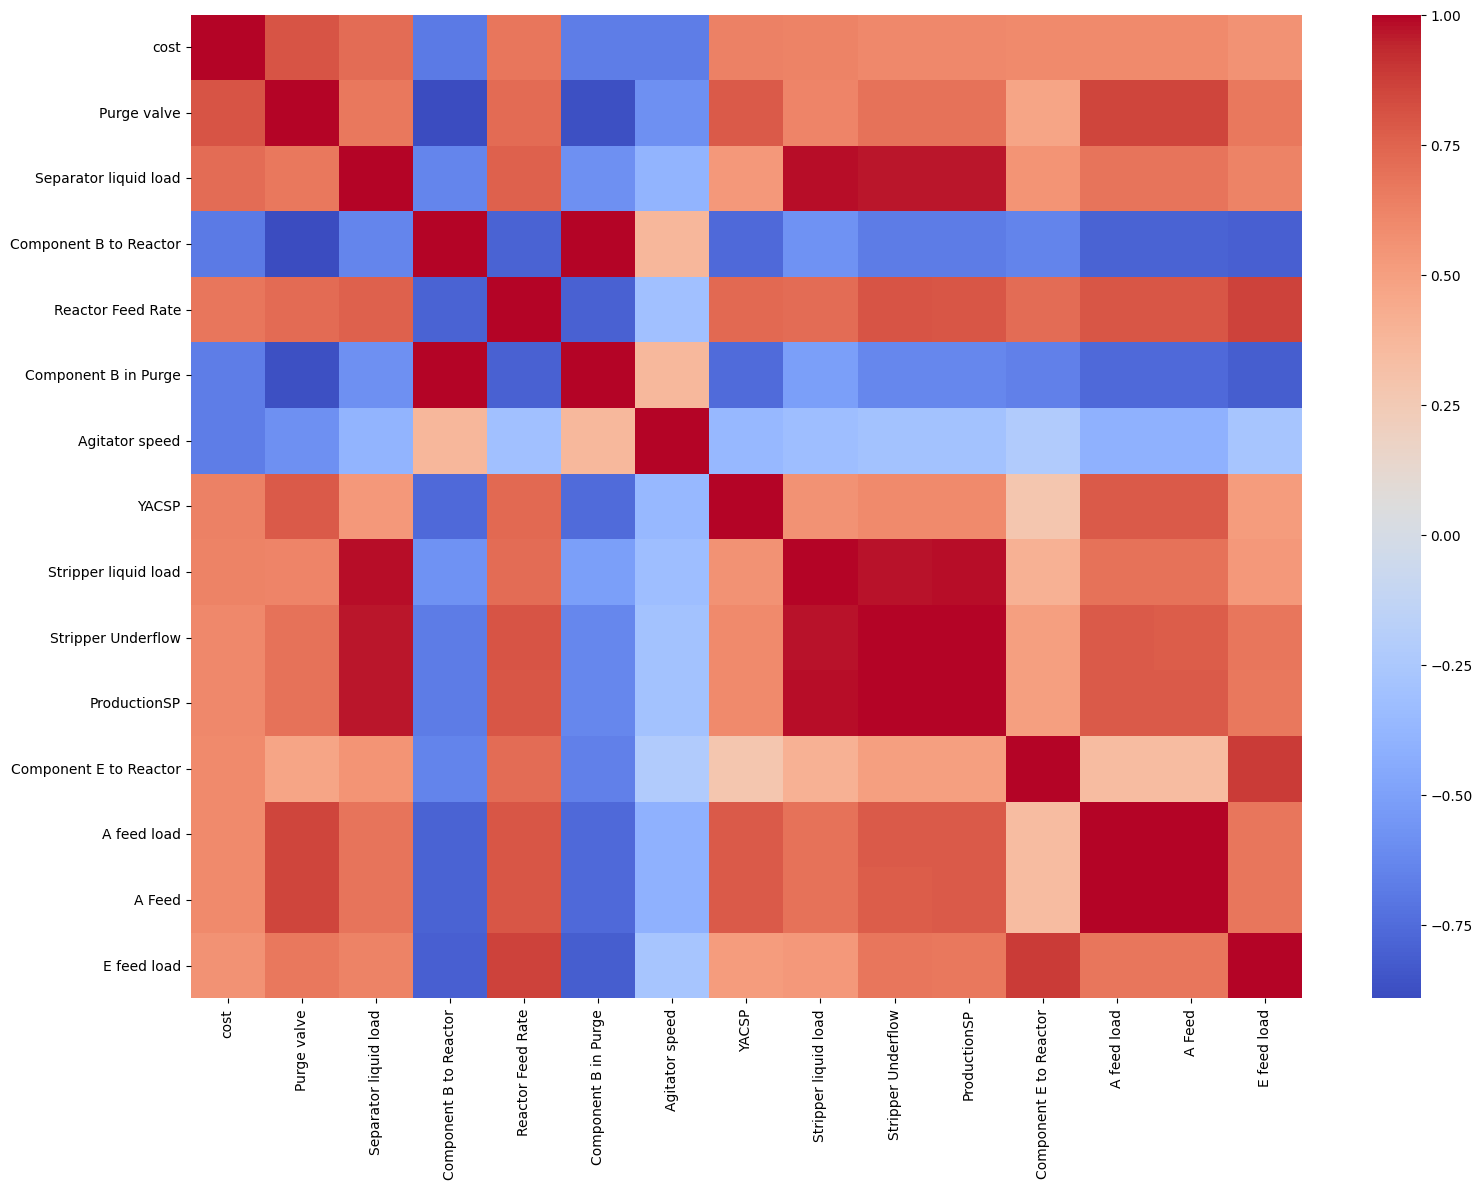

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 12))
sns.heatmap(corr.loc[main_corr[:15].index, main_corr[:15].index], cmap="coolwarm", annot=False, fmt=".2f")
plt.tight_layout()
plt.show()

Prepare training

In [17]:
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import LeaveOneOut, cross_val_score

def select_features(means: pd.DataFrame, candidates: list, n: int,
                    target: str="cost", required: list=()) -> list:
    """Vorwaertsselektion mit Leave-one-out-Kreuzvalidierung.

    Bewertet ein Merkmal an seinem Beitrag zur Vorhersage im Verbund und nicht
    an seiner Einzelkorrelation. Eine Rangliste nach |Korrelation| waehlt sonst
    mehrfach dieselbe physikalische Groesse (etwa Stellgroesse und zugehoerige
    Messung) und laesst schwach korrelierte, aber komplementaere Merkmale aus.
    """
    y = means[target].to_numpy()
    ridge = RidgeCV(alphas=np.logspace(-4, 3, 30))
    selected = [c for c in required if c in means.columns]
    rest = [c for c in candidates if c not in selected]
    for c in selected:
        print(f"  0. {c:26s} (gesetzt, Wirkort der Sensordrift)")
    while len(selected) < n and rest:
        scores = {c: -cross_val_score(ridge, means[selected + [c]].to_numpy(), y,
                                      cv=LeaveOneOut(),
                                      scoring="neg_mean_squared_error").mean()
                  for c in rest}
        best = min(scores, key=scores.get)
        selected.append(best)
        rest.remove(best)
        print(f"  {len(selected)}. {best:26s} LOO-RMSE = {np.sqrt(scores[best]):.4f}")
    return selected

feature_candidates = [c for c in setpoint_labels_update
                      if c not in ["time", "original_index", "mode", "cost", "reset"]
                      and not c.startswith("IDV")
                      and stationary_means[c].std() > 1e-9]
if FEATURE_MODE == "fixed":
    _unknown = [c for c in FEATURE_SET if c not in stationary_means.columns]
    if _unknown:
        raise KeyError(f"FEATURE_SET enthaelt unbekannte Spalten: {_unknown}")
    feature_cols = list(FEATURE_SET)
    print("Merkmalssatz fest vorgegeben (FEATURE_MODE = 'fixed'), begruendet"
          " ueber die Kostenzerlegung:")
    for _k, _c in enumerate(feature_cols, 1):
        print(f"  {_k}. {_c}")
elif FEATURE_MODE == "select":
    feature_cols = select_features(stationary_means, feature_candidates, N_FEATURES,
                                   required=[SENSOR_FEATURE])
else:
    raise ValueError(f"FEATURE_MODE = {FEATURE_MODE!r}, erwartet 'fixed' oder 'select'")

assert SENSOR_FEATURE in feature_cols, (
    "Wirkort der Sensordrift fehlt im Merkmalssatz")
len(feature_cols), feature_cols

Merkmalssatz fest vorgegeben (FEATURE_MODE = 'fixed'), begruendet ueber die Kostenzerlegung:
  1. Stripper Temp
  2. Purge valve
  3. Component E to Reactor
  4. Product Sep Temp
  5. MolePctGSP


(5,
 ['Stripper Temp',
  'Purge valve',
  'Component E to Reactor',
  'Product Sep Temp',
  'MolePctGSP'])

In [18]:
campaign_stationary_only = True

if campaign_stationary_only:
    campaign_preprocessed_data = pd.concat([campaign_smoothed_data.loc[(campaign_smoothed_data["original_index"]>=start) & 
                                      (campaign_smoothed_data["original_index"]<=end),:]
                                      for start, end in campaign_ranges])
else:
    campaign_preprocessed_data = campaign_smoothed_data.copy()

In [19]:
from sklearn.model_selection import train_test_split

x_temp = campaign_preprocessed_data.loc[:, feature_cols].values
y_temp = campaign_preprocessed_data.loc[:, "cost"].values
segment = is_val = None

if VAL_MODE == "ramp":
    # Trainiert wird auf den Halteintervallen *aller* Kampagnenpunkte,
    # validiert auf deren Anfahrrampen. Die Validierungsmenge deckt damit alle
    # Punkte ab statt drei, und die Kampagne verliert keine Stuetzstelle.
    _camp = campaign_smoothed_data[campaign_smoothed_data["mode"].isin(campaign_modes)]
    _val = _camp[static_ramp_mask(_camp, ramp_duration)]
    x_train, y_train = x_temp, y_temp
    x_val = _val.loc[:, feature_cols].values
    y_val = _val.loc[:, "cost"].values
    n_val_points = int(_val["mode"].nunique())
elif VAL_MODE == "segment":
    segment = np.zeros(len(campaign_preprocessed_data), dtype=int)
    original_index = campaign_preprocessed_data["original_index"].to_numpy()
    for i, (start, end) in enumerate(campaign_ranges):
        segment[(original_index >= start) & (original_index <= end)] = i
    n_val = max(1, round(VAL_SPLIT * len(campaign_ranges)))
    val_segments = rng.choice(np.unique(segment), n_val, replace=False)
    is_val = np.isin(segment, val_segments)
    x_train, y_train = x_temp[~is_val], y_temp[~is_val]
    x_val, y_val = x_temp[is_val], y_temp[is_val]
    n_val_points = int(len(val_segments))
elif VAL_MODE == "random":
    x_train, x_val, y_train, y_val = train_test_split(
        x_temp, y_temp, test_size=VAL_SPLIT, random_state=SEED)
    n_val_points = len(campaign_modes)
else:
    raise ValueError(f"VAL_MODE = {VAL_MODE!r}, erwartet 'ramp', 'segment' oder 'random'")

print(f"Validierung: {VAL_MODE}, {n_val_points} Betriebspunkte")
print(f"Train shape: {x_train.shape}, {y_train.shape}")
print(f"Validation shape: {x_val.shape}, {y_val.shape}")

Validierung: ramp, 18 Betriebspunkte
Train shape: (17314, 5), (17314,)
Validation shape: (17102, 5), (17102,)


## Train Neural network

In [20]:
model_params = {"arch": ARCH, "act": ACT, "opt": "adam", "epochs": EPOCHS,
                "batch": BATCH, "patience": PATIENCE, "val_split": VAL_SPLIT,
                "seed": SEED, "window_size": WINDOW_SIZE, "features": list(feature_cols),
                "drop_outliers": DROP_OUTLIERS, "val_mode": VAL_MODE,
                "sensor_feature": SENSOR_FEATURE,
                "feature_mode": FEATURE_MODE}

model_cfg = cfg.compose(model=model_params)
scored_error_cfg = model_cfg.compose(error=error_variant)

_model_loaded_from_cache = model_store.exists("model", model_cfg) and not FORCE_RECOMPUTE

# Einmalige Uebernahme des Altbestands (frueher model_cfg + variant-Token).
# Nach dem ersten erfolgreichen Lauf kann dieser Block entfallen.
if not data_store.exists("data_scored_error", scored_error_cfg) \
        and data_store.exists("data_scored_error", model_cfg, variant=error_variant):
    data_store.save(data_store.load("data_scored_error", model_cfg, variant=error_variant, rename=True),
                    "data_scored_error", scored_error_cfg)
    print(f"data_scored_error aus Altbestand uebernommen -> {scored_error_cfg.id}")

_scored_loaded_from_cache = (
    data_store.exists("data_scored_production", model_cfg)
    and data_store.exists("data_scored_error", scored_error_cfg)
    and not FORCE_RECOMPUTE
)

In [21]:
if _model_loaded_from_cache:
    _mc = model_store.load("model", model_cfg, rename=True)
    model, feature_cols = _mc["model"], _mc["feature_cols"]
    print(f"Modell aus Cache | Early Stopping nach {_mc.get('epochs_run', '?')} Epochen")
else:
    import tensorflow as tf
    from tensorflow import keras
    from keras import layers
    from keras.callbacks import EarlyStopping

    tf.keras.utils.set_random_seed(SEED)

    model = keras.Sequential(
        [layers.Input(shape=(len(feature_cols),))]
        + [layers.Dense(units, activation=ACT) for units in ARCH[:-1]]
        + [layers.Dense(ARCH[-1])]
    )

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    early_stop = EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)

    history = model.fit(
        x_train, y_train, 
        validation_data=(x_val, y_val),
        epochs=EPOCHS, 
        batch_size=BATCH, 
        callbacks=[early_stop], 
        verbose=1
    )
    _epochs_run = len(history.history["loss"])
    print(f"Early Stopping nach {_epochs_run} von {EPOCHS} Epochen "
          f"(Validierung: {VAL_MODE}, {n_val_points} Betriebspunkte)")
    model_store.save({"model": model, "feature_cols": list(feature_cols),
                      "window_size": WINDOW_SIZE, "epochs_run": _epochs_run},
               "model", model_cfg)

Epoch 1/200
87/87 [==============================] - 1s 5ms/step - loss: 0.1496 - mae: 0.2946 - val_loss: 0.0054 - val_mae: 0.0599
Epoch 2/200
87/87 [==============================] - 0s 3ms/step - loss: 0.0132 - mae: 0.0931 - val_loss: 0.0035 - val_mae: 0.0483
Epoch 3/200
87/87 [==============================] - 0s 3ms/step - loss: 0.0055 - mae: 0.0584 - val_loss: 0.0045 - val_mae: 0.0510
Epoch 4/200
87/87 [==============================] - 0s 3ms/step - loss: 0.0045 - mae: 0.0552 - val_loss: 0.0051 - val_mae: 0.0537
Epoch 5/200
87/87 [==============================] - 0s 3ms/step - loss: 0.0043 - mae: 0.0549 - val_loss: 0.0049 - val_mae: 0.0531
Epoch 6/200
87/87 [==============================] - 0s 4ms/step - loss: 0.0041 - mae: 0.0538 - val_loss: 0.0050 - val_mae: 0.0529
Epoch 7/200
87/87 [==============================] - 0s 4ms/step - loss: 0.0040 - mae: 0.0529 - val_loss: 0.0047 - val_mae: 0.0518
Epoch 8/200
87/87 [==============================] - 0s 3ms/step - loss: 0.0039 - m

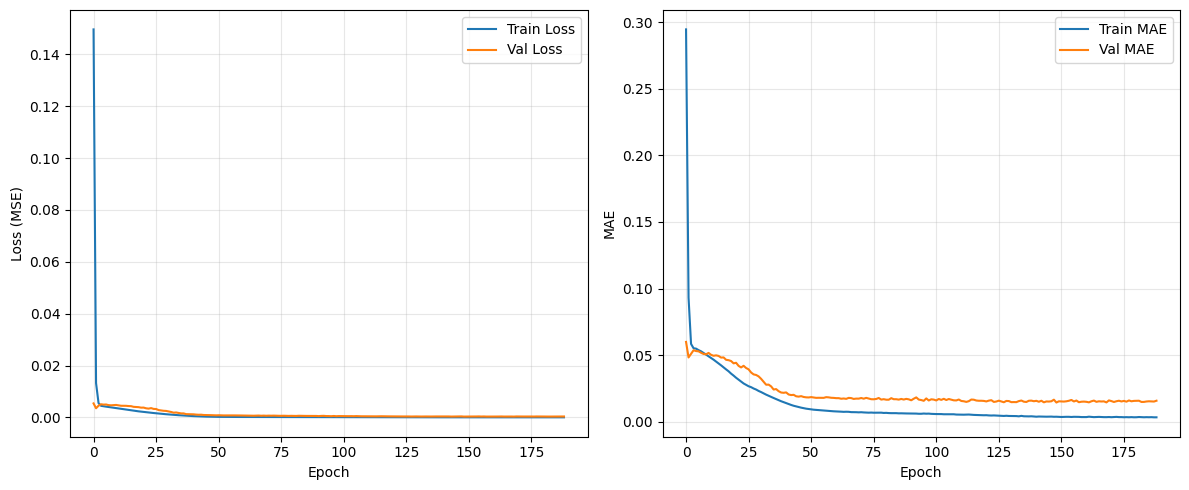

In [22]:
if not _model_loaded_from_cache:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label='Train MAE')
    plt.plot(history.history['val_mae'], label='Val MAE')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## Preprocess test data

Wird uebersprungen und aus dem Cache geladen, falls `data_scored_production` fuer diese `model_cfg` bereits existiert (analog zum Modell-Cache).

In [23]:
if _scored_loaded_from_cache:
    production_preprocessed_data = data_store.load("data_scored_production", model_cfg, rename=True)
    print(f"Scored-Produktionsdaten aus Cache geladen ({len(production_preprocessed_data)} Zeilen)")

In [24]:
if not _scored_loaded_from_cache:
    production_smoothed_data = preprocess(production_data, scaler)

In [25]:
if not _scored_loaded_from_cache:
    production_stationary_mask = static_steady_mask(production_smoothed_data, ramp_duration, soak_time)
    production_stationary_ranges = find_stationary_ranges(production_smoothed_data, production_stationary_mask, same_length=False)

In [26]:
if not _scored_loaded_from_cache:
    production_stationary_only = False

    if production_stationary_only:
        production_preprocessed_data = pd.concat([production_smoothed_data.loc[(production_smoothed_data["original_index"]>=start) & 
                                          (production_smoothed_data["original_index"]<=end),:]
                                          for start, end in production_stationary_ranges])
    else:
        production_preprocessed_data = production_smoothed_data.copy()

Add model predictions and model error to test data

In [27]:
if not _scored_loaded_from_cache:
    production_features = production_preprocessed_data[feature_cols].to_numpy(dtype="float32", copy=False)
    y_pred = model.predict(production_features)

    production_preprocessed_data.loc[:, "y_pred"] = y_pred
    production_preprocessed_data.loc[:, "model_error"] = production_preprocessed_data["y_pred"] - production_preprocessed_data["cost"]

    production_preprocessed_data.set_index("original_index", inplace=True)

10891/10891 [==============================] - 13s 1ms/step


In [28]:
if not _scored_loaded_from_cache:
    production_reset_indices = production_smoothed_data[production_smoothed_data["reset"] == True].index

In [29]:
if not _scored_loaded_from_cache:
    production_reset_indices

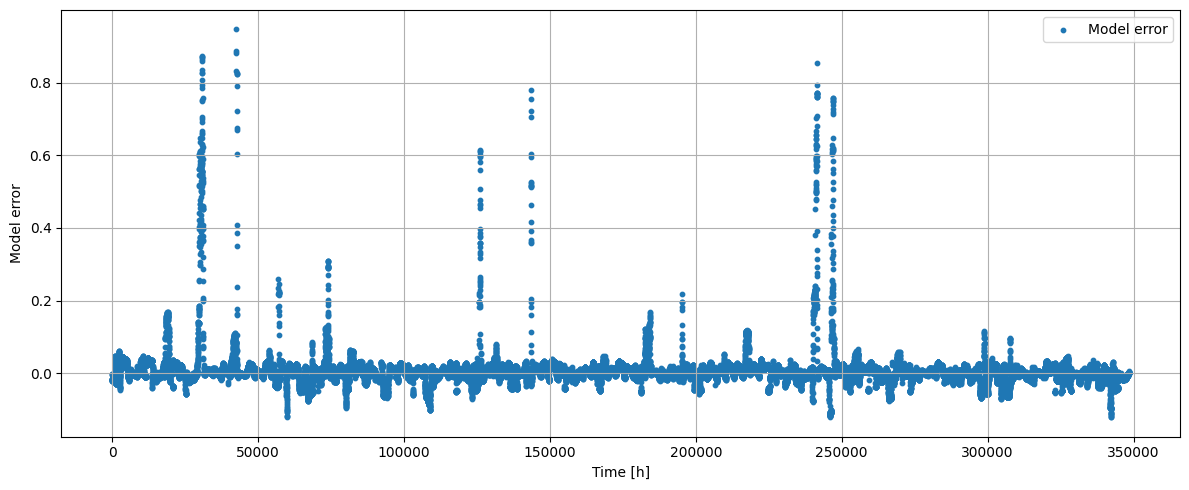

In [30]:
if not _scored_loaded_from_cache:
    production_data_sampled = production_preprocessed_data.sample(frac=.1, random_state=SEED)

    plt.figure(figsize=(12, 5))
    plt.scatter(production_data_sampled.index, production_data_sampled["model_error"], label="Model error", s=10)

    for i, reset_idx in enumerate(production_reset_indices):
        plt.axvline(reset_idx, color='red', linestyle='--', alpha=0.6, label='reset' if i == 0 else "")

    plt.xlabel("Time [h]")
    plt.ylabel("Model error")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [31]:
if not _scored_loaded_from_cache:
    data_store.save(production_preprocessed_data, "data_scored_production", model_cfg,
               meta={"feature_cols": list(feature_cols),
                     "stationary_ranges": [(int(s), int(e)) for s, e in production_stationary_ranges]})

## Preprocess error data

Wird uebersprungen und aus dem Cache geladen, falls `data_scored_error` fuer diese `model_cfg` bereits existiert.

In [32]:
if _scored_loaded_from_cache:
    error_preprocessed_data = data_store.load("data_scored_error", scored_error_cfg, rename=True)
    print(f"Scored-Fehlerdaten aus Cache geladen ({len(error_preprocessed_data)} Zeilen)")

In [33]:
if not _scored_loaded_from_cache:
    error_smoothed_data = preprocess(error_data, scaler)

In [34]:
if not _scored_loaded_from_cache:
    error_stationary_mask = static_steady_mask(error_smoothed_data,
                                               ramp_duration, soak_time)
    error_stationary_ranges = find_stationary_ranges(error_smoothed_data,
                                                     error_stationary_mask,
                                                     same_length=False)

In [35]:
if not _scored_loaded_from_cache:
    error_stationary_only = production_stationary_only

    if error_stationary_only:
        error_preprocessed_data = pd.concat([error_smoothed_data.loc[(error_smoothed_data["original_index"]>=start) & 
                                          (error_smoothed_data["original_index"]<=end),:]
                                          for start, end in error_stationary_ranges])
    else:
        error_preprocessed_data = error_smoothed_data.copy()

Add model predictions and model error to error data

In [36]:
if not _scored_loaded_from_cache:
    error_features = error_preprocessed_data[feature_cols].to_numpy(dtype="float32", copy=False)
    y_pred = model.predict(error_features)

    error_preprocessed_data.loc[:, "y_pred"] = y_pred
    error_preprocessed_data.loc[:, "model_error"] = error_preprocessed_data["y_pred"] - error_preprocessed_data["cost"]

    error_preprocessed_data.set_index("original_index", inplace=True)

10891/10891 [==============================] - 15s 1ms/step


In [37]:
if not _scored_loaded_from_cache:
    error_reset_indices = error_smoothed_data[error_smoothed_data["reset"] == True].index

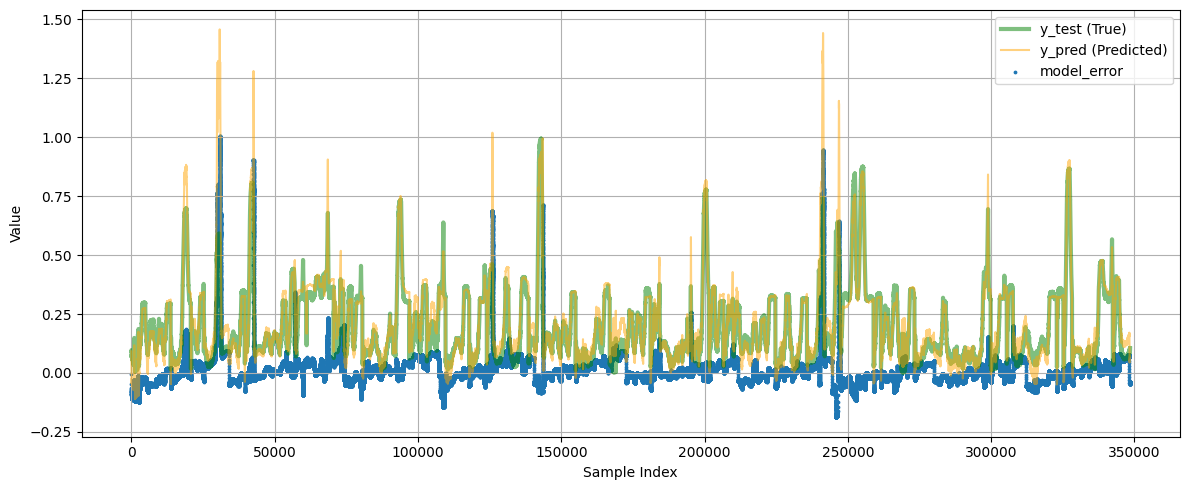

In [38]:
if not _scored_loaded_from_cache:
    plt.figure(figsize=(12, 5))
    plt.plot(error_preprocessed_data["cost"], label="y_test (True)", alpha=0.5, linewidth=3, color="green")
    plt.plot(error_preprocessed_data["y_pred"], label="y_pred (Predicted)", alpha=0.5, color="orange")
    plt.scatter(error_preprocessed_data.index, error_preprocessed_data["model_error"], label="model_error", s=3)

    for i, reset_idx in enumerate(error_reset_indices):
        plt.axvline(reset_idx, color='red', linestyle='--', alpha=0.6, label='reset' if i == 0 else "")

    plt.xlabel("Sample Index")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [39]:
if not _scored_loaded_from_cache:
    data_store.save(error_preprocessed_data, "data_scored_error", scored_error_cfg)

## Vergleich Modellfehler: nominal vs. Fehlerfall

Stellt den Modellfehler des nominalen Testlaufs und des Fehlerfalls modeweise gegenüber,
normiert beide mit Mittelwert und Streuung des nominalen Testfehlers (identisch zu
*tep_detection*) und legt das rekonstruierte Driftsignal $c(t)$ auf die zweite Ordinate.

In [40]:
# Modellfehler modeweise gegenueberstellen. Die Simulationszeit des Fehlerlaufs
# wird mitgefuehrt, da sie das Argument des Driftsignals ist (sie beginnt nach
# jedem Reset wieder bei 0, wie drift_tonset in temexd_mod.c).
combined = []

for mode in production_preprocessed_data["mode"].unique():
    production_temp = (production_preprocessed_data.loc[production_preprocessed_data["mode"] == mode,
                                            ["model_error"]]
                 .reset_index(drop=True))
    fault_temp = (error_preprocessed_data.loc[error_preprocessed_data["mode"] == mode,
                                              ["model_error", "time", "reset",
                                               "driftf", "drift_segment"]]
                  .reset_index(drop=True))
    combined.append(pd.concat([production_temp, fault_temp], axis=1))

combined_data = pd.concat(combined, axis=0, ignore_index=True)
combined_data.columns = ["model_error_normal", "model_error_fault",
                         "time_fault", "reset_fault", "driftf", "drift_segment"]


### Fehler normieren

Der Modellfehler wird mit Mittelwert und Streuung des nominalen Testfehlers normiert,
damit die Ordinate dieselbe Bedeutung hat wie im synthetischen Fall und in *tep_detection*.

In [41]:
_err_free = production_preprocessed_data["model_error"].to_numpy(dtype=float)
NORM_MEAN = float(np.nanmean(_err_free))
NORM_STD = float(np.nanstd(_err_free)) or 1.0

for _c in ("normal", "fault"):
    combined_data[f"error_norm_{_c}"] = (
        (combined_data[f"model_error_{_c}"] - NORM_MEAN) / NORM_STD)

# Darstellungszeit als Zeitstempel (analog syn_generation): der Strom ist eine
# Zeitreihe, die Achse traegt Monatsticks. Davon unabhaengig ist "time_fault",
# die Simulationszeit je Lauf, die das Driftsignal argumentiert.
t_h = combined_data.index.to_numpy(dtype=float) / SAMPLES_PER_H
plot_index = pd.to_datetime(t_h * 3600.0, unit="s", origin=pd.Timestamp(PLOT_EPOCH))

_z = combined_data[["error_norm_normal", "error_norm_fault"]].to_numpy(dtype=float)
print(f"{len(combined_data)} Zeitschritte ({t_h[-1]:.0f} h, bis {plot_index[-1]:%d.%m.%Y}) | "
      f"Normierung: mean={NORM_MEAN:.4g}, std={NORM_STD:.4g}")
print(f"Norm. Fehler: max|z|={np.nanmax(np.abs(_z)):.1f}, "
      f"99.9%-Quantil={np.nanquantile(np.abs(_z), 0.999):.1f} "
      f"-> PLOT_YLIM ggf. anpassen")


348481 Zeitschritte (17424 h, bis 28.12.1971) | Normierung: mean=0.007747, std=0.06036
Norm. Fehler: max|z|=16.5, 99.9%-Quantil=13.0 -> PLOT_YLIM ggf. anpassen


### Driftsignal

Das Driftsignal wird nicht mehr aus `DRIFT_PERIOD` rekonstruiert, sondern aus den Daten gelesen: `driftf` steht als Spalte in `data_error` und ist als Verhältnis der aufgezeichneten Strippertemperatur punktweise exakt. Damit hängt keine Auswertung mehr an einer C-Übersetzung, die nachweislich vom Simulator abweicht.


In [42]:
# Gemessenes Driftsignal statt Rekonstruktion.  Weil die Sensordrift den Prozess
# nicht beruehrt (Delta_y = 0), ist driftf = Stripper Temp(Fehler)/Stripper
# Temp(nominal) punktweise exakt; die Spalte kommt aus tep_generation.  Der
# frueher hier stehende Python-Port von drift_function_sawtooth.c ist entfallen:
# er zeigt dieselbe Abweichung vom Simulator wie die DLL (RMS 0.018, also 38 %
# des Signaleffektivwerts) und wird nicht mehr gebraucht.
cd_signal = combined_data["driftf"].to_numpy(dtype=float) - 1.0

_seg = combined_data.groupby("drift_segment")["time_fault"].agg(["min", "max", "count"])
print(f"Driftsignal (gemessen): min={np.nanmin(cd_signal):.3f}, "
      f"max={np.nanmax(cd_signal):.3f} | "
      f"Kalibrierfaktor in [{1 + np.nanmin(cd_signal):.4f}, {1 + np.nanmax(cd_signal):.4f}]")
print(f"{len(_seg)} Driftsegmente:")
print(_seg.to_string(float_format=lambda v: f"{v:.1f}"))

Driftsignal (gemessen): min=-0.138, max=0.147 | Kalibrierfaktor in [0.8625, 1.1470]
12 Driftsegmente:
                  min     max  count
drift_segment                       
0                 0.0     0.0      1
1                 0.1  1693.7  33873
2              1693.7  3652.5  39177
3              3652.6  5390.1  34751
4              5390.1  7018.2  32563
5              7018.2  8623.0  32095
6              8623.0 10581.2  39165
7             10581.2 12216.0  32696
8             12216.1 14002.6  35731
9             14002.6 15613.9  32227
10            15614.0 17413.5  35993
11            17413.6 17424.0    209


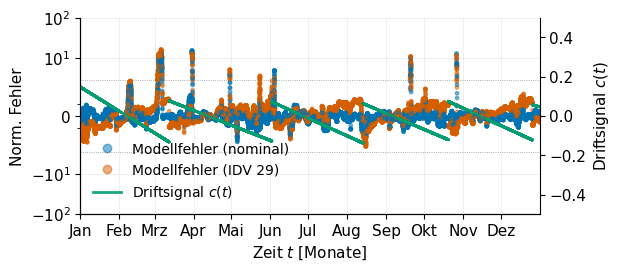

In [43]:
import matplotlib.pyplot as plt
from src.utils import thesis_style as ts

rng_plot = np.random.default_rng(SEED)

PLOT_MONTHS = 12   # None -> alles

_m = slice(None)
if PLOT_MONTHS is not None:
    _m = (plot_index < pd.Timestamp(PLOT_EPOCH) + pd.DateOffset(months=PLOT_MONTHS)).nonzero()[0]

fig, ax, ax2 = ts.error_timeseries(
    plot_index[_m],
    [(combined_data["error_norm_normal"].to_numpy(dtype=float)[_m],
      "drift_free", "Modellfehler (nominal)"),
     (combined_data["error_norm_fault"].to_numpy(dtype=float)[_m],
      "drift_afflicted", f"Modellfehler (IDV {ERROR_VARIANT_ID})")],
    cd=cd_signal[_m],
    ylabel="Norm. Fehler",
        xlabel="Zeit $t$ [Monate]",
        cd_label="Driftsignal $c(t)$",
        ylim=PLOT_YLIM, cd_amp=0.5, cd_tick_step=0.2,
        frac=PLOT_FRAC, rng=rng_plot, height_scale=0.45,
        legend=dict(loc="lower left", markerscale=1),
)
fig.tight_layout()
plt.show()

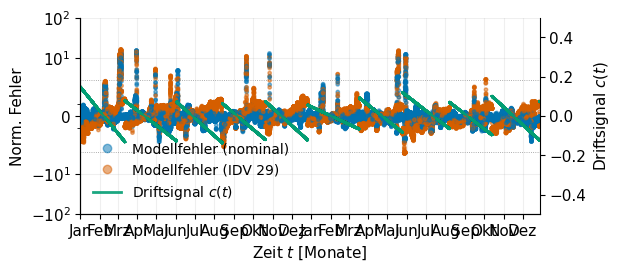

In [44]:
import matplotlib.pyplot as plt
from src.utils import thesis_style as ts

rng_plot = np.random.default_rng(SEED)

fig, ax, ax2 = ts.error_timeseries(
    plot_index,
    [(combined_data["error_norm_normal"].to_numpy(dtype=float),
      "drift_free", "Modellfehler (nominal)"),
     (combined_data["error_norm_fault"].to_numpy(dtype=float),
      "drift_afflicted", f"Modellfehler (IDV {ERROR_VARIANT_ID})")],
    cd=cd_signal,
    ylabel="Norm. Fehler",
    xlabel="Zeit $t$ [Monate]",
    cd_label="Driftsignal $c(t)$",
    ylim=PLOT_YLIM, cd_amp=0.5, cd_tick_step=0.2,
    frac=PLOT_FRAC, rng=rng_plot, height_scale=0.45,
    legend=dict(loc="lower left", markerscale=1),
)
fig.tight_layout()
plot_store.save_figure(fig, "error", scored_error_cfg, final=IS_FINAL,
                       savefig_kwargs={"dpi": 300}, archive_kwargs={"dpi": 300})
plt.show()


## Numerische Auswertung der Modelldegradation

In [45]:
# Kennzahlen getrennt nach gesehenen und ungesehenen Betriebspunkten.  Nur die
# ungesehenen tragen die Aussage -- die gesehenen sind exakte Wiederholungen von
# Kampagnenpunkten und damit der Anker fuer Abstand null.
_seen = production_preprocessed_data["mode"].isin(campaign_modes).to_numpy()
_r0 = production_preprocessed_data["model_error"].to_numpy(dtype=float)
_r1 = error_preprocessed_data["model_error"].to_numpy(dtype=float)
_seen_e = error_preprocessed_data["mode"].isin(campaign_modes).to_numpy()

def _stats(a, b):
    return dict(rmse_free=np.sqrt(np.nanmean(a ** 2)),
                rmse_fault=np.sqrt(np.nanmean(b ** 2)),
                std_free=np.nanstd(a), bias_fault=np.nanmean(b),
                std_fault=np.nanstd(b),
                K=np.sqrt(np.nanmean(b ** 2)) / (np.sqrt(np.nanmean(a ** 2)) or np.nan))

# Die Zeilennamen gehen unveraendert in die LaTeX-Makronamen (Zelle
# "LaTeX-Makros"). Leerzeichen und Klammern sind dort nicht zulaessig.
stats = pd.DataFrame({
    "Alle": _stats(_r0, _r1),
    "Ungesehen": _stats(_r0[~_seen], _r1[~_seen_e]),
    "Gesehen": _stats(_r0[_seen], _r1[_seen_e]),
}).T
pd.set_option("display.float_format", lambda v: f"{v:.4g}")
print(stats.to_string())
print(f"\n{int((~_seen).sum())} von {len(_seen)} Zeilen auf ungesehenen Punkten "
      f"({production_preprocessed_data.loc[~_seen, 'mode'].nunique()} Betriebspunkte)")

# Fuer den Ergebnis-Export bleibt die Zeile ueber die ungesehenen Punkte massgeblich.
r0, r1 = _r0[~_seen], _r1[~_seen_e]

           rmse_free  rmse_fault  std_free  bias_fault  std_fault     K
Alle         0.06086     0.07599   0.06036     0.01357    0.07477 1.249
Ungesehen    0.06378     0.07933   0.06317     0.01614    0.07767 1.244
Gesehen      0.03623     0.04866   0.03622    -0.00327    0.04855 1.343

302401 von 348481 Zeilen auf ungesehenen Punkten (105 Betriebspunkte)


## Modellfehler über dem Abstand zur Kampagne

Der eigentliche Ertrag der modusweisen Datengrundlage. Für jeden Produktionspunkt der Abstand zum nächsten Kampagnenpunkt im skalierten Sollwertraum gegen den Modellfehler. Daraus wird begründet, bis zu welcher Abweichung vom Versuchsplan der Drift sichtbar bleibt — statt diese Grenze zu setzen.


In [46]:
## Fehler je Betriebspunkt und Abstand zum naechsten Kampagnenpunkt
# Der Abstand wird in zwei Raeumen gemessen:
#   Sollwerte  -- der Entwurfsraum, in dem die Kampagne geplant wird
#   Merkmale   -- der Raum, den das Modell tatsaechlich sieht
# Nur der zweite ist fuer den Modellfehler kausal: ein Punkt kann in Sollwerten
# fern und in Merkmalen nah liegen. Gebinnt wird nach DIST_SPACE.
DIST_SPACE = "feature"        # "feature" | "setpoint"

_pm = static_steady_mask(production_preprocessed_data, ramp_duration, soak_time)
_em = static_steady_mask(error_preprocessed_data, ramp_duration, soak_time)
_ph, _eh = production_preprocessed_data[_pm], error_preprocessed_data[_em]

_rms = lambda s: float(np.sqrt(np.nanmean(np.asarray(s, float) ** 2)))
point = pd.DataFrame({
    "err_free": _ph.groupby("mode")["model_error"].apply(_rms),
    "err_fault": _eh.groupby("mode")["model_error"].apply(_rms),
    "cost": _ph.groupby("mode")["cost"].mean(),
})
point["d_e"] = (_eh.groupby("mode")["model_error"].mean()
                - _ph.groupby("mode")["model_error"].mean()).abs()
point["gesehen"] = point.index.isin(campaign_modes)


def _min_dist(cols):
    """Abstand je Produktionspunkt zum naechsten Kampagnenpunkt, skaliert auf
    die Spannweite des Kampagnenpools."""
    lo, hi = campaign_means_all[cols].min(), campaign_means_all[cols].max()
    span = (hi - lo).replace(0.0, 1.0)
    up = (_ph.groupby("mode")[cols].mean() - lo) / span
    uc = (campaign_means_all.loc[campaign_modes, cols] - lo) / span
    return cdist(up.to_numpy(), uc.to_numpy()).min(axis=1)


point["dist_sp"] = _min_dist(setpoint_cols)
point["dist_feat"] = _min_dist(list(feature_cols))
_dcol = "dist_feat" if DIST_SPACE == "feature" else "dist_sp"

print(f"{len(point)} Produktionspunkte, davon {int(point['gesehen'].sum())} gesehen")
print(f"Abstand Sollwertraum ({len(setpoint_cols)}D): "
      f"{point['dist_sp'].min():.3f} .. {point['dist_sp'].max():.3f}")
print(f"Abstand Merkmalsraum ({len(feature_cols)}D): "
      f"{point['dist_feat'].min():.3f} .. {point['dist_feat'].max():.3f}")
_ung = ~point["gesehen"]
for _c in ("dist_sp", "dist_feat"):
    print(f"  corr(err_free, {_c:9s}) ueber die ungesehenen Punkte = "
          f"{np.corrcoef(point.loc[_ung, _c], point.loc[_ung, 'err_free'])[0, 1]:+.3f}")

print("\nZerlegung von RMSE_frei:")
for _lab, _sel in (("gesehen (Abstand 0)", point["gesehen"]), ("ungesehen", _ung)):
    if _sel.any():
        print(f"  {_lab:22s} n={int(_sel.sum()):3d}  RMSE {_rms(point.loc[_sel, 'err_free']):7.4f}"
              f"  Abstand Median {point.loc[_sel, _dcol].median():.3f}")

_edges = np.quantile(point.loc[_ung, _dcol], np.linspace(0, 1, 6))
_edges[0], _edges[-1] = _edges[0] - 1e-9, _edges[-1] + 1e-9
point["klasse"] = pd.cut(point[_dcol], np.unique(_edges))
_curve = point.groupby("klasse", observed=True).agg(
    n=("err_free", "size"), abstand=(_dcol, "median"),
    rmse_frei=("err_free", _rms), d_e=("d_e", "mean"))
_curve["verhaeltnis"] = _curve["d_e"] / _curve["rmse_frei"]
print(f"\nAbstandsklassen im {DIST_SPACE}-Raum:")
print(_curve.to_string(float_format=lambda v: f"{v:.4f}"))
print("\nverhaeltnis > 1 heisst: die driftbedingte Verschiebung uebersteigt den")
print("nominalen Fehler -- ab dort ist der Drift im Modellfehler sichtbar.")

121 Produktionspunkte, davon 16 gesehen
Abstand Sollwertraum (12D): 0.000 .. 1.097
Abstand Merkmalsraum (5D): 0.000 .. 0.693
  corr(err_free, dist_sp  ) ueber die ungesehenen Punkte = -0.049
  corr(err_free, dist_feat) ueber die ungesehenen Punkte = +0.325

Zerlegung von RMSE_frei:
  gesehen (Abstand 0)    n= 16  RMSE  0.0056  Abstand Median 0.001
  ungesehen              n=105  RMSE  0.0618  Abstand Median 0.222

Abstandsklassen im feature-Raum:
                  n  abstand  rmse_frei    d_e  verhaeltnis
klasse                                                     
(0.0371, 0.105]  21   0.0750     0.0165 0.0281       1.7047
(0.105, 0.193]   22   0.1421     0.0226 0.0317       1.3993
(0.193, 0.288]   21   0.2225     0.0533 0.0325       0.6100
(0.288, 0.391]   21   0.3385     0.0310 0.0325       1.0501
(0.391, 0.693]   21   0.5043     0.1203 0.0345       0.2864

verhaeltnis > 1 heisst: die driftbedingte Verschiebung uebersteigt den
nominalen Fehler -- ab dort ist der Drift im Modellfehler

In [47]:
## Driftwirkung je Segment
_seg_tbl = (combined_data.groupby("drift_segment")
            .agg(n=("model_error_fault", "size"),
                 t_min=("time_fault", "min"), t_max=("time_fault", "max"),
                 driftf_min=("driftf", "min"), driftf_max=("driftf", "max"),
                 rmse_frei=("model_error_normal", _rms),
                 rmse_fehler=("model_error_fault", _rms)))
_seg_tbl["K"] = _seg_tbl["rmse_fehler"] / _seg_tbl["rmse_frei"]
print(_seg_tbl.to_string(float_format=lambda v: f"{v:.3f}"))

# Korrelation der Fehlerverschiebung mit dem Driftsignal, je Segment
print("\nKorrelation (Fehlerdifferenz, driftf) je Segment:")
for _s, _g in combined_data.groupby("drift_segment"):
    _dy = (_g["model_error_fault"] - _g["model_error_normal"]).to_numpy(dtype=float)
    _ok = np.isfinite(_dy) & np.isfinite(_g["driftf"].to_numpy(dtype=float))
    if _ok.sum() > 10:
        print(f"  Segment {int(_s)}: n={int(_ok.sum()):6d}  "
              f"corr = {np.corrcoef(_dy[_ok], _g['driftf'].to_numpy(float)[_ok])[0, 1]:+.3f}")

                   n     t_min     t_max  driftf_min  driftf_max  rmse_frei  rmse_fehler      K
drift_segment                                                                                  
0                  1     0.000     0.000       1.000       1.000      0.002        0.002  1.000
1              33873     0.050  1693.650       0.868       1.147      0.117        0.158  1.344
2              39177  1693.700  3652.500       0.872       1.077      0.063        0.066  1.057
3              34751  3652.550  5390.050       0.862       1.072      0.033        0.045  1.371
4              32563  5390.100  7018.200       0.879       1.063      0.048        0.067  1.403
5              32095  7018.250  8622.950       0.877       1.074      0.043        0.054  1.258
6              39165  8623.000 10581.200       0.933       1.055      0.024        0.031  1.272
7              32696 10581.250 12216.000       0.917       1.092      0.095        0.113  1.193
8              35731 12216.050 14002.550

## Screening: Kampagnengröße

Eigene Zelle, damit `N_CAMPAIGN` im Hauptlauf ein Skalar bleibt. Alles hier ist lokal (`_sw`-Präfix), der Zustand des Notebooks wird nicht verändert — Modell, Merkmalssatz und Kennzahlen oben bleiben die des eingestellten `N_CAMPAIGN`.

Für jede Größe werden Merkmalsauswahl und Netz neu gerechnet und auf den **ungesehenen** Produktionspunkten bewertet. Bei der vollen Poolgröße gibt es keine ungesehenen mehr; diese Zeile ist das Szenario „wiederkehrende Betriebspunkte" aus Handoff 10.1.


In [48]:
SWEEP_SIZES = (12, 18, 30, 60, 90)
SWEEP_VAL_MODES = ("segment", "ramp")   # Merkmalssatz bleibt FEATURE_MODE
RUN_SWEEP = True     # nach dem Screening auf False setzen

if RUN_SWEEP:
    import contextlib, io
    import tensorflow as tf
    from tensorflow import keras
    from keras import layers
    from keras.callbacks import EarlyStopping

    _sw_pm = static_steady_mask(production_preprocessed_data, ramp_duration, soak_time)
    _sw_em = static_steady_mask(error_preprocessed_data, ramp_duration, soak_time)
    _sw_ph = production_preprocessed_data[_sw_pm]
    _sw_eh = error_preprocessed_data[_sw_em]
    _sw_rms = lambda a: float(np.sqrt(np.nanmean(np.asarray(a, float) ** 2)))

    def _sw_run(n, val_mode):
        _modes = pick_campaign(n)
        _means, _ranges = campaign_subset(_modes)
        if FEATURE_MODE == "fixed":
            _feat = list(FEATURE_SET)
        else:
            with contextlib.redirect_stdout(io.StringIO()):
                _feat = select_features(_means, feature_candidates, N_FEATURES,
                                        required=[SENSOR_FEATURE])
        _tr = pd.concat([campaign_smoothed_data.loc[
            (campaign_smoothed_data["original_index"] >= s)
            & (campaign_smoothed_data["original_index"] <= e), :] for s, e in _ranges])
        _x, _y = _tr[_feat].to_numpy("float32"), _tr["cost"].to_numpy("float32")

        if val_mode == "ramp":
            _c = campaign_smoothed_data[campaign_smoothed_data["mode"].isin(_modes)]
            _v = _c[static_ramp_mask(_c, ramp_duration)]
            _xtr, _ytr = _x, _y
            _xv = _v[_feat].to_numpy("float32"); _yv = _v["cost"].to_numpy("float32")
            _nvp = int(_v["mode"].nunique())
        else:
            _segid = np.zeros(len(_tr), dtype=int)
            _oi = _tr["original_index"].to_numpy()
            for k, (s, e) in enumerate(_ranges):
                _segid[(_oi >= s) & (_oi <= e)] = k
            _nval = max(1, round(VAL_SPLIT * len(_ranges)))
            _vseg = np.random.default_rng(SEED).choice(np.unique(_segid), _nval,
                                                       replace=False)
            _isv = np.isin(_segid, _vseg)
            _xtr, _ytr = _x[~_isv], _y[~_isv]
            _xv, _yv = _x[_isv], _y[_isv]
            _nvp = int(len(_vseg))

        tf.keras.utils.set_random_seed(SEED)
        _m = keras.Sequential([layers.Input(shape=(len(_feat),))]
                              + [layers.Dense(u, activation=ACT) for u in ARCH[:-1]]
                              + [layers.Dense(ARCH[-1])])
        _m.compile(optimizer="adam", loss="mse")
        _hist = _m.fit(_xtr, _ytr, validation_data=(_xv, _yv),
                       epochs=EPOCHS, batch_size=BATCH, verbose=0,
                       callbacks=[EarlyStopping(monitor="val_loss", patience=PATIENCE,
                                                restore_best_weights=True)])

        _unseen_p = ~_sw_ph["mode"].isin(_modes).to_numpy()
        _unseen_e = ~_sw_eh["mode"].isin(_modes).to_numpy()
        if _unseen_p.sum() < 100:      # keine ungesehenen Punkte mehr
            _unseen_p[:] = True; _unseen_e[:] = True
        _r0 = (_m.predict(_sw_ph[_feat].to_numpy("float32"), verbose=0).ravel()
               - _sw_ph["cost"].to_numpy())[_unseen_p]
        _r1 = (_m.predict(_sw_eh[_feat].to_numpy("float32"), verbose=0).ravel()
               - _sw_eh["cost"].to_numpy())[_unseen_e]
        _f = _sw_rms(_r0)
        return dict(n_kampagne=n, variante=val_mode,
                    n_ungesehen=int(_sw_ph.loc[_unseen_p, "mode"].nunique()),
                    n_val_pt=_nvp, n_train=len(_xtr),
                    epochen=len(_hist.history["loss"]),
                    rmse_frei=_f, rmse_fehler=_sw_rms(_r1),
                    K=_sw_rms(_r1) / (_f or np.nan))

    sweep = pd.DataFrame([_sw_run(n, v) for n in SWEEP_SIZES
                          if n <= len(campaign_means_all) for v in SWEEP_VAL_MODES])
    _piv = sweep.pivot(index="n_kampagne", columns="variante",
                       values=["rmse_frei", "K", "epochen", "n_val_pt"])
    _piv[("n", "ungesehen")] = sweep.groupby("n_kampagne")["n_ungesehen"].first()
    print(_piv.to_string(float_format=lambda v: f"{v:.4f}"))
    print(f"\nMerkmalssatz: {FEATURE_MODE}"
          + (f" -> {', '.join(FEATURE_SET)}" if FEATURE_MODE == "fixed" else ""))
    print(f"Eingestellt: N_CAMPAIGN = {N_CAMPAIGN}, VAL_MODE = {VAL_MODE!r}, "
          f"amp = {error_variant['amp']}.")
    print("\nEin Abbruch nahe PATIENCE + 1 = "
          f"{PATIENCE + 1} bedeutet, dass die beste Epoche die erste war -- das")
    print("Early Stopping hat dann nicht die Anpassung gemessen, sondern Rauschen.")

           rmse_frei              K          epochen         n_val_pt                 n
variante        ramp segment   ramp segment     ramp segment     ramp segment ungesehen
n_kampagne                                                                             
12            0.0890  0.1141 1.1979  1.1227  22.0000 28.0000  12.0000  2.0000       110
18            0.0618  0.1162 1.3064  1.1072 189.0000 27.0000  18.0000  3.0000       105
30            0.0391  0.0408 1.5234  1.4738 119.0000 63.0000  30.0000  4.0000        94
60            0.0181  0.0183 2.0054  1.9729  61.0000 56.0000  60.0000  9.0000        67
90            0.0195  0.0204 1.9979  1.9263  71.0000 54.0000  90.0000 14.0000        40

Merkmalssatz: fixed -> Stripper Temp, Purge valve, Component E to Reactor, Product Sep Temp, MolePctGSP
Eingestellt: N_CAMPAIGN = 18, VAL_MODE = 'ramp', amp = 0.3.

Ein Abbruch nahe PATIENCE + 1 = 21 bedeutet, dass die beste Epoche die erste war -- das
Early Stopping hat dann nicht die Anpassun

## Ergebnisse speichern

In [49]:
from src.utils import results_export as rx

_keys = [(k, k, "num") for k in
         ["rmse_free", "rmse_fault", "std_free", "bias_fault", "std_fault"]]

(rx.ResultDoc()
   .integer("n_test", len(production_preprocessed_data))
   .integer("n_error", len(error_preprocessed_data))
   .stats(stats, _keys, into="models")
   .save(res_store, "error", scored_error_cfg, final=IS_FINAL))

Umfassende Ergebnisse -> C:\git\process_optimization_concept_drift\results\tep_error.json


'C:\\git\\process_optimization_concept_drift\\results\\tep_error.json'

In [50]:
def _de(x, nd):
    if x is None or (isinstance(x, float) and x != x):
        return "--"
    return f"{x:.{nd}f}".replace(".", "{,}")

_keys = [("rmse_free", "RmseFree", 3), ("rmse_fault", "RmseFault", 3),
         ("std_free", "SigmaFree", 3), ("bias_fault", "Bias", 3),
         ("std_fault", "Sigma", 3), ("K", "K", 3)]
import re as _re

def _macro_safe(s):
    """LaTeX-Makronamen duerfen nur Buchstaben enthalten."""
    return _re.sub(r"[^A-Za-z]", "", str(s))

_lines = ["% automatisch erzeugt aus tep_model.ipynb - nicht manuell editieren"]
for m in stats.index:
    for col, suf, nd in _keys:
        _lines.append(rf"\newcommand{{\tepstat{_macro_safe(m)}{suf}}}"
                      rf"{{{_de(stats.loc[m, col], nd)}}}")
_tex = "\n".join(_lines) + "\n"
_pt, _ = res_store.save_text(_tex, "tep_model_error_stats", scored_error_cfg, final=IS_FINAL)
print(f"LaTeX-Makros -> {_pt}\n")
print(_tex)

LaTeX-Makros -> C:\git\process_optimization_concept_drift\results\tep_tep_model_error_stats.tex

% automatisch erzeugt aus tep_model.ipynb - nicht manuell editieren
\newcommand{\tepstatAlleRmseFree}{0{,}061}
\newcommand{\tepstatAlleRmseFault}{0{,}076}
\newcommand{\tepstatAlleSigmaFree}{0{,}060}
\newcommand{\tepstatAlleBias}{0{,}014}
\newcommand{\tepstatAlleSigma}{0{,}075}
\newcommand{\tepstatAlleK}{1{,}249}
\newcommand{\tepstatUngesehenRmseFree}{0{,}064}
\newcommand{\tepstatUngesehenRmseFault}{0{,}079}
\newcommand{\tepstatUngesehenSigmaFree}{0{,}063}
\newcommand{\tepstatUngesehenBias}{0{,}016}
\newcommand{\tepstatUngesehenSigma}{0{,}078}
\newcommand{\tepstatUngesehenK}{1{,}244}
\newcommand{\tepstatGesehenRmseFree}{0{,}036}
\newcommand{\tepstatGesehenRmseFault}{0{,}049}
\newcommand{\tepstatGesehenSigmaFree}{0{,}036}
\newcommand{\tepstatGesehenBias}{-0{,}003}
\newcommand{\tepstatGesehenSigma}{0{,}049}
\newcommand{\tepstatGesehenK}{1{,}343}



## Lauf abgeschlossen

Zeigt die Kennungen dieses Laufs in einem Fenster mit Kopier-Button (Konsolenausgabe, falls keine GUI verfuegbar ist).

In [51]:
from src.utils.dialogs import show_with_copy_button

show_with_copy_button(
    "Lauf abgeschlossen",
    f"Modellbildung beendet.\n"
    f"Model Run-ID: {model_cfg.id}\n"
    f"Fehlerfall (IDV {ERROR_VARIANT_ID}): {scored_error_cfg.id}",
    copy_value=model_cfg.id,
)


--- Lauf abgeschlossen ---
Modellbildung beendet.
Model Run-ID: e37ec0b5
Fehlerfall (IDV 29): 3c2a0310

